https://www.kaggle.com/datasets/abdullah0a/telecom-customer-churn-insights-for-analysis

Dataset Telecom Customer Churn Insights for Analysis trên Kaggle là một tập dữ liệu kinh điển dùng cho bài toán Dự đoán khách hàng rời bỏ dịch vụ (Customer Churn Prediction) trong lĩnh vực viễn thông.

1. Mục tiêu của Dataset
Giúp các nhà mạng viễn thông dự đoán xem khách hàng nào có nguy cơ hủy dịch vụ (rời bỏ công ty) để đưa ra các chính sách chăm sóc và giữ chân kịp thời.

Đây là một bài toán phân loại nhị phân (Binary Classification) rất phổ biến trong kinh doanh (Business Analytics).

2. Cấu trúc các cột dữ liệu (Features)
Dataset thường bao gồm khoảng 10 cột đặc trưng chính (tùy phiên bản file CSV cụ thể) phản ánh thông tin nhân khẩu học, thông tin tài khoản và mức độ sử dụng dịch vụ:

CustomerID: Mã định danh duy nhất của từng khách hàng.

Age: Độ tuổi của khách hàng.

Gender: Giới tính (Nam/Nữ).

Tenure: Số tháng khách hàng đã sử dụng dịch vụ của nhà mạng (thời gian gắn bó).

MonthlyCharges: Số tiền cước phí mà khách hàng phải trả hàng tháng.

TotalCharges: Tổng số tiền khách hàng đã thanh toán tính từ lúc bắt đầu sử dụng dịch vụ.

ContractType: Hình thức hợp đồng (ví dụ: theo tháng Month-to-Month, hợp đồng 1 năm One-Year, v.v.).

InternetService: Loại dịch vụ internet mà khách hàng đăng ký (Cáp quang Fiber Optic, DSL, hoặc không dùng).

TechSupport: Khách hàng có đăng ký gói hỗ trợ kỹ thuật hay không (Yes/No).

Churn (Biến mục tiêu - Target): Khách hàng có rời bỏ nhà mạng trong tháng vừa qua hay không (Yes = Đã rời đi, No = Tiếp tục ở lại).

3. Thách thức khi phân tích dataset này
Dữ liệu thiếu (Missing Values): Một số cột như InternetService thường xuất hiện giá trị trống (NaN) cần phải xử lý bằng cách điền giá trị xuất hiện nhiều nhất (mode).

Biến hỗn hợp: Bao gồm cả dữ liệu số (Age, Tenure, MonthlyCharges) và dữ liệu chữ phân loại (Gender, ContractType, TechSupport) nên cần mã hóa (Label Encoding hoặc One-Hot Encoding) trước khi đưa vào mô hình Machine Learning.

In [1]:
import pandas as pd

df = pd.read_csv("customer_churn_data.csv")

In [2]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [3]:
df.tail()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
995,996,42,Male,41,37.14,Month-to-Month,Fiber Optic,1522.74,Yes,Yes
996,997,62,Male,9,80.93,Month-to-Month,NaN,728.37,No,Yes
997,998,51,Female,15,111.72,Month-to-Month,Fiber Optic,1675.80,Yes,Yes
998,999,39,Male,68,65.67,One-Year,NaN,4465.56,No,Yes
999,1000,50,Male,1,56.67,Month-to-Month,NaN,56.67,No,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [5]:
df.isna().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [7]:
df["InternetService"] = df["InternetService"].fillna("")

In [8]:
df.isna().sum()

CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [11]:
numeric_colums_data = df.select_dtypes(include=["number"])

In [14]:
numeric_colums_data.corr()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


In [15]:
df["Churn"].value_counts()

Churn
Yes    883
No     117
Name: count, dtype: int64

In [18]:
import matplotlib.pyplot as plt

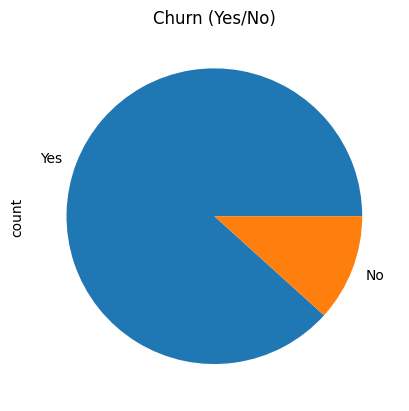

In [19]:
df["Churn"].value_counts().plot(kind="pie")
plt.title("Churn (Yes/No)")
plt.show()

In [20]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [21]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

In [23]:
df.groupby(["Churn", "Gender"])["MonthlyCharges"].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [24]:
df.groupby("Churn")["Tenure"].mean()

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

In [26]:
df.groupby("Churn")["Age"].mean()

Churn
No     43.487179
Yes    44.831257
Name: Age, dtype: float64

Text(0.5, 1.0, 'Contract Type Average Price')

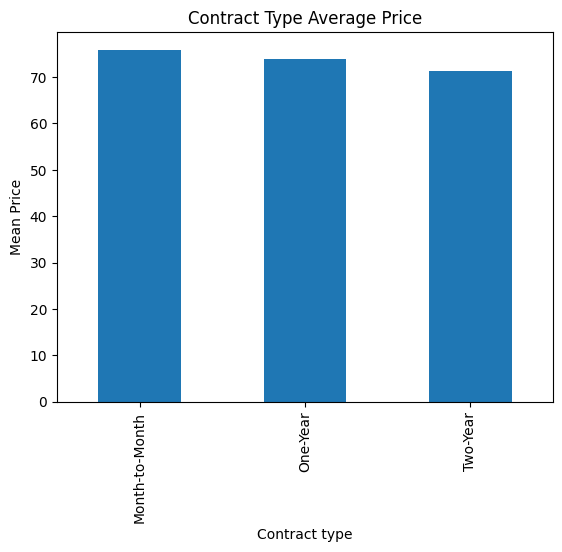

In [30]:
df.groupby("ContractType")["MonthlyCharges"].mean().plot(kind="bar")
plt.ylabel("Mean Price")
plt.xlabel("Contract type")
plt.title("Contract Type Average Price")

Text(0.5, 1.0, 'Histogram of Monthly Charges')

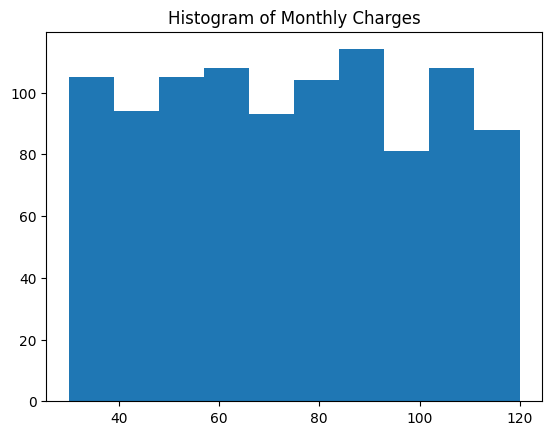

In [31]:
plt.hist(df["MonthlyCharges"])
plt.title("Histogram of Monthly Charges")

Text(0.5, 1.0, 'Histogram of Tenura')

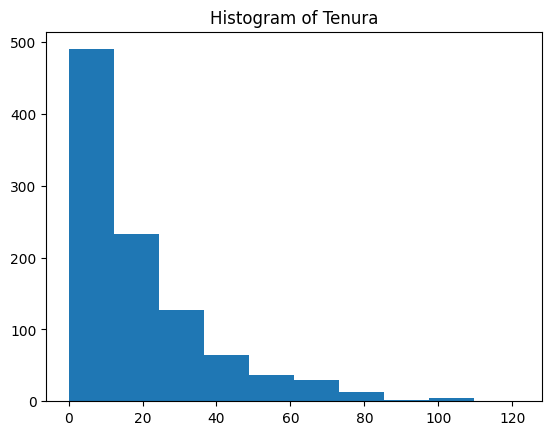

In [32]:
plt.hist(df["Tenure"])
plt.title("Histogram of Tenura")


In [33]:
y = df[["Churn"]]
X = df[["Age", "Gender", "Tenure", "MonthlyCharges"]]

In [35]:
X["Gender"] = X["Gender"].apply(lambda x: 1 if x == "Femail" else 0)

C:\Users\mbw2025\AppData\Local\Temp\ipykernel_10772\3738003430.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Gender"] = X["Gender"].apply(lambda x: 1 if x == "Femail" else 0)


In [36]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,0,2,63.79
3,60,0,8,102.34
4,42,0,32,69.01
...,...,...,...,...
995,42,0,41,37.14
996,62,0,9,80.93
997,51,0,15,111.72
998,39,0,68,65.67


In [38]:
type(X["Gender"][0])

numpy.int64

In [39]:
y["Churn"] = y["Churn"].apply(lambda x: 1 if x =="Yes" else 0)

C:\Users\mbw2025\AppData\Local\Temp\ipykernel_10772\1807528793.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y["Churn"] = y["Churn"].apply(lambda x: 1 if x =="Yes" else 0)


In [40]:
y

,Churn
0,1
1,1
2,1
3,1
4,1
...,...
995,1
996,1
997,1
998,1


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

In [42]:
from sklearn.preprocessing import StandardScaler

In [43]:
scaler = StandardScaler()

In [44]:
X_train

,Age,Gender,Tenure,MonthlyCharges
336,36,0,0,71.25
231,47,0,63,98.34
157,49,0,8,63.58
779,51,0,40,81.78
801,39,0,2,37.34
...,...,...,...,...
14,27,0,14,95.05
90,45,0,9,51.91
733,27,0,20,62.44
555,40,0,5,40.47


In [45]:
X_train = scaler.fit_transform(X_train)

In [46]:
X_train

array([[-0.86161138,  0.        , -1.03114692, -0.10454749],
       [ 0.26635353,  0.        ,  2.46520701,  0.96910128],
       [ 0.47143806,  0.        , -0.58716547, -0.40853   ],
       ...,
       [-1.78449177,  0.        ,  0.07880671, -0.45371123],
       [-0.45144232,  0.        , -0.75365851, -1.32444078],
       [-1.27178044,  0.        , -0.53166779, -0.22939037]],
      shape=(800, 4))

In [47]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

1. joblib.dump(scaler, "scaler.pkl") đang lưu cái gì?
Lúc bạn chạy lệnh scaler.fit_transform(X_train) ở phần train mô hình, bộ StandardScaler đã làm 2 việc:

Học dữ liệu: Nó quét qua toàn bộ tập dữ liệu huấn luyện (X_train) và tính toán ra giá trị trung bình (mean) và độ lệch chuẩn (standard deviation) của từng cột (ví dụ: tuổi trung bình là bao nhiêu, cước phí trung bình là bao nhiêu...).

Ghi nhớ: Nó lưu cứng các con số trung bình và độ lệch chuẩn đó vào bên trong biến scaler.

➡️ joblib.dump(scaler, "scaler.pkl") chính là đem "cái khuôn" đã ghi nhớ các con số chuẩn đó đóng gói và lưu ra một file riêng tên là scaler.pkl trên máy tính.

Mục đích: Để sau này khi viết code giao diện (app.py), dù chương trình tắt đi bật lại, bạn vẫn tải lại được đúng cái khuôn chuẩn đó mà không phải tính toán lại từ đầu.

2. X_array là gì và các giá trị bên trong nó biểu thị cái gì?
Dòng lệnh:

Python


X_array = scaler.transform([X1])
Hoạt động theo các bước sau:

X1 là gì? Là dãy số liệu thô mà người dùng vừa nhập trực tiếp trên giao diện web Streamlit (ví dụ: [Age: 30, Tenure: 12, MonthlyCharges: 70.5...]). Đây là dữ liệu thực tế ngoài đời, chưa hề qua chuẩn hóa.

scaler.transform(...) làm gì? Nó lấy dữ liệu thô X1 này áp dụng vào cái khuôn đã tải từ file scaler.pkl ở trên.

X_array nhận được giá trị gì?

X_array chứa các con số đã được chuẩn hóa theo điểm Z (Z-score).

Thay vì giữ nguyên giá trị thật (như tuổi 30 hay cước 70.5), nó sẽ tính toán xem giá trị này nằm cách giá trị trung bình bao nhiêu khoảng độ lệch chuẩn.

Ví dụ: X_array sau khi biến đổi có thể trông như thế này: [[-0.45, 1.2, -0.8]].

In [48]:
X_test = scaler.fit_transform(X_test)

In [49]:
from sklearn.metrics import accuracy_score

def modelperformance(predictions):
    print("Accuracy score on model is {}".format(accuracy_score(y_test, predictions)))

định nghĩa một hàm Python giúp tự động tính toán và in ra độ chính xác (Accuracy) của mô hình bằng cách so sánh kết quả dự đoán với nhãn thực tế.

In [50]:
from sklearn.linear_model import LogisticRegression

In [51]:
log_model = LogisticRegression()

In [52]:
log_model.fit(X_train, y_train)

c:\Users\mbw2025\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [53]:
import warnings
warnings.filterwarnings("ignore")

In [58]:
y_pred = log_model.predict(X_test)

In [61]:
modelperformance(y_pred)

Accuracy score on model is 1.0


In [62]:
from sklearn.neighbors import KNeighborsClassifier

In [63]:
param_grid = {
    "n_neighbors": [3,5,7,9],
    "weights": ["uniform", "distance"]
}

để thiết lập lưới tham số (param_grid) nhằm tối ưu hóa thuật toán K-Nearest Neighbors (KNN - K láng giềng gần nhất).

Bản chất của KNN: Thuật toán này phân loại một khách hàng mới dựa trên "hàng xóm" của nó. Nếu những khách hàng có đặc điểm (tuổi, cước phí,...) gần giống khách hàng này trong tập dữ liệu mà phần lớn là "Churn" (rời bỏ), thì nó sẽ phán đoán khách hàng mới này cũng sẽ Churn.

2. param_grid = { ... }
Biến này định nghĩa các cấu hình/tham số khác nhau để thử nghiệm (thường dùng kết hợp với các công cụ tìm kiếm như GridSearchCV):

"n_neighbors": [3, 5, 7, 9]:

Định nghĩa số lượng "láng giềng" (hàng xóm) sẽ được mang ra xem xét.

Ví dụ nếu chọn 5, mô hình sẽ nhìn vào 5 khách hàng cũ có thông số gần nhất để đưa ra quyết định. Việc thử nhiều giá trị khác nhau (3, 5, 7, 9) giúp tìm ra con số nào mang lại độ chính xác cao nhất, tránh tình trạng quá ít láng giềng (dễ bị nhiễu) hoặc quá nhiều láng giềng (bị loãng thông tin).

"weights": ["uniform", "distance"]:

Quyết định cách tính trọng số của các láng giềng:

"uniform": Mọi láng giềng đều có quyền quyết định như nhau (dù ở gần hay ở xa một chút).

"distance": Láng giềng nào nằm ở càng gần khách hàng mới thì tiếng nói càng có trọng lượng (quyết định mạnh hơn) so với những láng giềng ở xa.

In [64]:
from sklearn.model_selection import GridSearchCV
gridkn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)

1. GridSearchCV(...)Đây là một công cụ cực kỳ mạnh mẽ trong Scikit-learn. Nó sẽ tự động "thử nghiệm tất cả các trường hợp" có thể xảy ra từ lưới tham số param_grid mà bạn đã định nghĩa ở bước trước (tổng cộng sẽ có $4 \text{ (số láng giềng)} \times 2 \text{ (cách tính trọng số)} = 8$ tổ hợp cấu hình khác nhau).Sau khi thử xong, nó sẽ tự động chọn ra bộ tham số nào mang lại hiệu quả tốt nhất.

cv=5 (Cross-Validation / Kiểm định chéo 5 phần):

Thay vì chỉ chia tập dữ liệu thành 1 phần train và 1 phần test đơn thuần, phương pháp này sẽ chia tập huấn luyện thành 5 phần bằng nhau.

Mô hình sẽ được train 5 lần: lần 1 dùng 4 phần để học và 1 phần để kiểm tra, lần 2 đổi phần kiểm tra sang vị trí khác,... Cứ thế cho đến hết để lấy điểm trung bình chính xác nhất. Việc này giúp đảm bảo kết quả đánh giá mô hình là khách quan, không bị ăn may do chọn nhầm tập test.

In [65]:
gridkn.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,9


In [66]:
gridkn.best_params_

{'n_neighbors': 9, 'weights': 'uniform'}

In [67]:
y_pred = gridkn.predict(X_test)

In [68]:
modelperformance(y_pred)

Accuracy score on model is 0.915


In [69]:
from sklearn.svm import SVC

In [70]:
svm = SVC()

In [71]:
param_grid = {
    "C": [0.01,0.1,0.5,1],
    "kernel": ["linear", "rbf", "poly"]
}

Dòng này nhập thuật toán SVC (Support Vector Classification) từ thư viện Scikit-learn để chuyên giải quyết các bài toán phân loại nhị phân (như phân loại khách hàng Churn hay Không Churn).

Bản chất của SVM: Thuật toán sẽ tìm một đường ranh giới (hoặc mặt phẳng/siêu phẳng) tối ưu nhất trong không gian nhiều chiều để tách biệt rõ ràng giữa nhóm khách hàng rời bỏ và nhóm khách hàng ở lại.

2. param_grid = { ... }
Đây là các siêu tham số (hyperparameters) mà bạn muốn đưa vào để thử nghiệm tìm ra cấu hình tốt nhất:

"C": [0.01, 0.1, 0.5, 1] (Hệ số điều regularization/phạt):

Quyết định mức độ phạt của mô hình đối với các điểm dữ liệu bị phân loại sai.

C giá trị nhỏ (0.01, 0.1): Cho phép biên mềm mại hơn, chấp nhận một vài lỗi sai để đường ranh giới mượt mà, tránh hiện tượng học vẹt (overfitting).

C giá trị lớn (0.5, 1): Ép mô hình phải phân loại đúng nhiều điểm dữ liệu nhất có thể trên tập train, ranh giới sẽ khắt khe hơn.

"kernel": ["linear", "rbf", "poly"] (Hàm nhân/Kernel):

Quyết định cách thức SVM vẽ ra đường ranh giới để chia cắt dữ liệu:

"linear": Đường ranh giới dạng đường thẳng/phẳng. Phù hợp với dữ liệu đơn giản.

"rbf" (Radial Basis Function): Đường ranh giới dạng đường cong/vòng tròn phức tạp. Rất mạnh trong việc xử lý các mối quan hệ phi tuyến tính trong thực tế.

"poly" (Polynomial): Đường ranh giới dạng đa thức (bậc cao).

In [72]:
gridsvc = GridSearchCV(svm, param_grid, cv=5)

In [73]:
gridsvc.fit(X_train, y_train)

,estimator,SVC()
,param_grid,"{'C': [0.01, 0.1, ...], 'kernel': ['linear', 'rbf', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.01


In [74]:
gridsvc.best_params_

{'C': 0.01, 'kernel': 'linear'}

In [76]:
y_pred = gridsvc.predict(X_test)

In [77]:
modelperformance(y_pred)

Accuracy score on model is 0.905


In [78]:
from sklearn.tree import DecisionTreeClassifier

In [79]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"],
    "max_depth": [None, 10,20,30],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

thuật toán Cây Quyết Định (Decision Tree Classifier). Đây là một trong những thuật toán trực quan và dễ hiểu nhất trong Machine Learning, hoạt động dựa trên việc đặt ra các câu hỏi dạng "Đúng/Sai" (Yes/No) theo từng nhánh để đưa ra phán đoán cuối cùng (khách hàng Churn hay không).

2. Chi tiết các tham số trong param_grid:
"criterion": ["gini", "entropy"] (Tiêu chuẩn đo lường độ tinh khiết):

Quyết định cách cây chọn câu hỏi để chia cắt dữ liệu ở mỗi nhánh (node) sao cho sau khi chia, các nhóm tách ra càng "thuần nhất" càng tốt.

"gini": Dựa trên độ bất tinh khiết Gini (Gini Impurity). Thường tính toán nhanh hơn.

"entropy": Dựa trên độ hỗn loạn thông tin / độ lợi thông tin (Information Gain).

"splitter": ["best", "random"] (Chiến lược phân nhánh):

"best": Thuật toán sẽ tìm kiếm cách chia tốt nhất có thể ở mọi điểm ngã rẽ (ưu tiên tối ưu hóa độ chính xác).

"random": Chọn ngẫu nhiên một cách chia trong một tập hợp các cách chia tốt (giúp tăng tính đa dạng, đôi khi giảm hiện tượng học vẹt).

"max_depth": [None, 10, 20, 30] (Độ sâu tối đa của cây):

Quyết định cây được phép mọc dài tối đa bao nhiêu tầng.

None: Cây cứ mọc thoải mái cho đến khi phân loại hoàn toàn sạch các mẫu (rất dễ dẫn đến Overfitting - học vẹt).

Các số 10, 20, 30: Giới hạn tầng của cây, ép mô hình phải khái quát hóa tốt hơn.

"min_samples_split": [2, 5, 10] (Số mẫu tối thiểu để được phép tách nhánh):

Nếu một nhánh chỉ còn lại ít hơn số lượng này (ví dụ ít hơn 5 khách hàng), cây sẽ dừng lại và không cố tách nhỏ thêm nữa để tránh học theo các điểm dữ liệu nhiễu.

"min_samples_leaf": [1, 2, 4] (Số mẫu tối thiểu tại một lá cuối cùng):

Đảm bảo rằng sau khi chia cắt, mỗi nhánh lá cuối cùng phải chứa ít nhất một số lượng mẫu nhất định, giúp mô hình ổn định hơn khi gặp dữ liệu mới.

In [80]:
grid_tree = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)

In [81]:
grid_tree.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [82]:
grid_tree.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 4,
 'min_samples_split': 10,
 'splitter': 'random'}

In [83]:
y_pred = grid_tree.predict(X_test)

In [84]:
modelperformance(y_pred)

Accuracy score on model is 0.85


In [85]:
from sklearn.ensemble import RandomForestClassifier

rfc_model = RandomForestClassifier()

In [86]:
param_grid = {
    "n_estimators": [32,64,128,256],
    "max_features": [2,3,4],
    "bootstrap": [True, False]
}

Random Forest là một trong những thuật toán cực kỳ mạnh mẽ và phổ biến bậc nhất trong Machine Learning hiện đại, hoạt động dựa trên nguyên lý kết hợp hàng loạt "cây quyết định" đơn lẻ lại với nhau để đưa ra kết quả cuối cùng theo kiểu "đám đông bỏ phiếu".

2. Chi tiết các siêu tham số trong param_grid:
"n_estimators": [32, 64, 128, 256] (Số lượng cây quyết định trong rừng):

Quyết định xem "rừng" của bạn sẽ được tạo thành từ bao nhiêu cái cây độc lập.

Ý nghĩa: Số lượng cây càng lớn thì mô hình càng ổn định, dự đoán càng chính xác và ít bị nhiễu, nhưng đổi lại thời gian huấn luyện (training time) sẽ lâu hơn. Việc thử các mốc tăng dần (32, 64, 128, 256) giúp tìm ra điểm cân bằng giữa tốc độ và độ chính xác.

"max_features": [2, 3, 4] (Số lượng đặc trưng tối đa được xem xét ở mỗi ngã rẽ):

Khi mỗi cái cây trong rừng phải đưa ra quyết định chia nhánh, thay vì nhìn toàn bộ các cột dữ liệu (ví dụ dataset có 10 cột), nó sẽ chỉ bốc ngẫu nhiên một số lượng cột nhất định (ở đây là 2, 3 hoặc 4 cột) để tìm cách chia tối ưu.

Ý nghĩa: Giúp các cây trong rừng có tính "độc lập" và khác biệt nhau, tránh tình trạng tất cả các cây đều đưa ra một kiểu phán đoán giống hệt nhau (tăng độ đa dạng cho tập thể).

"bootstrap": [True, False] (Phương pháp lấy mẫu dữ liệu cho từng cây):

True: Mỗi cái cây trong rừng sẽ được huấn luyện trên một tập con dữ liệu được bốc thăm ngẫu nhiên có hoàn lại (gọi là phương pháp Bagging). Điều này giúp mô hình chống hiện tượng học vẹt (overfitting) rất tốt.

False: Sử dụng toàn bộ tập dữ liệu gốc cho mỗi cây (ít khi dùng hơn trừ khi bạn muốn ép cây tận dụng toàn bộ dữ liệu).

In [87]:
grid_rfc = GridSearchCV(rfc_model, param_grid, cv=5)

In [88]:
grid_rfc.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'bootstrap': [True, False], 'max_features': [2, 3, ...], 'n_estimators': [32, 64, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,128


In [89]:
grid_rfc.best_params_

{'bootstrap': True, 'max_features': 3, 'n_estimators': 128}

In [90]:
y_pred = grid_rfc.predict(X_test)

In [91]:
modelperformance(y_pred)

Accuracy score on model is 0.895


In [93]:
best_model = gridsvc.best_estimator_

In [94]:
joblib.dump(best_model, "model.pkl")

['model.pkl']

In [95]:
X.columns

Index(['Age', 'Gender', 'Tenure', 'MonthlyCharges'], dtype='object')